# ДЗ №5. Задача классификации на kaggle

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import re
import numpy as np
import pandas as pd


TEMP_MAP = {"O": 0, "B": 1, "A": 2, "F": 3, "G": 4, "K": 5, "M": 6}
LUM_MAP = {"I": 1, "II": 2, "III": 3, "IV": 4, "V": 5}

def parse_sptype(s):
    """
    На вход строка вида 'G5/G6V', 'M1V:', 'F3V', 'G3IV', 'G6III' и т.п.
    Возвращает (temp_code, subclass, lum_code_num)
    """
    if pd.isna(s):
        return np.nan, np.nan, np.nan
    s = str(s).strip().replace(" ", "").replace(":", "")
    temp_char = s[0]
    temp_code = TEMP_MAP.get(temp_char, np.nan)
    nums = re.findall(r"\d+", s)
    if len(nums) == 0:
        subclass = np.nan
    else:
        nums_float = [float(n) for n in nums]
        subclass = float(np.mean(nums_float))
    lum_code_num = np.nan
    for lum_str in ["III", "II", "IV", "V", "I"]:
        if lum_str in s:
            lum_code_num = LUM_MAP[lum_str]
            break

    return temp_code, subclass, lum_code_num

def bv_to_temp(bv):
    if pd.isna(bv):
        return np.nan
    return 4600 * (1/(0.92*bv + 1.7) + 1/(0.92*bv + 0.62))

def plx_to_distance(plx):
    if pd.isna(plx) or plx <= 0:
        return np.nan
    return 1000.0 / plx

def compute_absolute_mag(Vmag, dist_pc):
    if pd.isna(dist_pc) or dist_pc <= 0:
        return np.nan
    return Vmag - 5 * np.log10(dist_pc) + 5

In [26]:
train = pd.read_csv("train_star.csv")
test = pd.read_csv("test_star.csv")
train.head()

,Vmag,Plx,e_Plx,B-V,SpType,Amag,TargetClass
0,9.99,7.92,1.61,0.646,G5/G6V,19.483625,Giant
1,10.86,3.26,2.12,1.840,M1V:,18.426088,Giant
2,8.83,7.57,1.05,0.461,F3V,18.225480,Giant
3,7.72,24.80,0.89,0.613,G3IV,19.692257,Giant
4,8.81,3.17,1.03,0.872,G6III,16.315296,Dwarf


In [22]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20732 entries, 0 to 20731
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Vmag         20732 non-null  float64
 1   Plx          20732 non-null  float64
 2   e_Plx        20732 non-null  float64
 3   B-V          20732 non-null  float64
 4   SpType       20732 non-null  object 
 5   Amag         20732 non-null  float64
 6   TargetClass  20732 non-null  object 
dtypes: float64(5), object(2)
memory usage: 1.1+ MB


In [6]:
train.columns

Index(['Vmag', 'Plx', 'e_Plx', 'B-V', 'SpType', 'Amag', 'TargetClass'], dtype='object')

Заменим метки классов на числа: гигант - 1, карлик - 0

In [7]:
train = train.map(lambda value: {"Giant": 1, "Dwarf": 0}.get(value, value))
test = test.map(lambda value: {"Giant": 1, "Dwarf": 0}.get(value, value))

In [8]:
train["SpType"].nunique()

1681

In [27]:
train[["Sp_temp", "Sp_subclass", "Sp_lum"]] = \
    train["SpType"].apply(lambda x: pd.Series(parse_sptype(x)))

test[["Sp_temp", "Sp_subclass", "Sp_lum"]] = \
    test["SpType"].apply(lambda x: pd.Series(parse_sptype(x)))

# Температура
train["T_eff"] = train["B-V"].apply(bv_to_temp)
test["T_eff"]  = test["B-V"].apply(bv_to_temp)

# Расстояние
train["Dist_pc"] = train["Plx"].apply(plx_to_distance)
test["Dist_pc"]  = test["Plx"].apply(plx_to_distance)

# Абсолютная величина M_V
train["M_V"] = train.apply(lambda r: compute_absolute_mag(r.Vmag, r.Dist_pc), axis=1)
test["M_V"]  = test.apply(lambda r: compute_absolute_mag(r.Vmag, r.Dist_pc), axis=1)

# Логарифмы
for col in ["T_eff", "Dist_pc"]:
    train[f"log_{col}"] = np.log10(train[col].clip(lower=1e-6))
    test[f"log_{col}"]  = np.log10(test[col].clip(lower=1e-6))


train = train.drop("SpType", axis=1)
test = test.drop("SpType", axis=1)

train.head()

,Vmag,Plx,e_Plx,B-V,Amag,TargetClass,Sp_temp,Sp_subclass,Sp_lum,T_eff,Dist_pc,M_V,log_T_eff,log_Dist_pc
0,9.99,7.92,1.61,0.646,19.483625,Giant,4.0,5.5,5.0,5793.079693,126.262626,4.483626,3.762910,2.101275
1,10.86,3.26,2.12,1.840,18.426088,Giant,6.0,1.0,5.0,3344.743474,306.748466,3.426088,3.524363,2.486782
2,8.83,7.57,1.05,0.461,18.225480,Giant,3.0,3.0,5.0,6571.226571,132.100396,3.225479,3.817646,2.120904
3,7.72,24.80,0.89,0.613,19.692257,Giant,4.0,3.0,4.0,5917.104412,40.322581,4.692258,3.772109,1.605548
4,8.81,3.17,1.03,0.872,16.315296,Dwarf,4.0,6.0,3.0,5072.687407,315.457413,1.315296,3.705238,2.498941


In [28]:
nun_sum = train.isna().sum()
print(nun_sum[nun_sum > 0])

Sp_temp         14
Sp_subclass     11
Dist_pc        398
M_V            398
log_Dist_pc    398
dtype: int64


In [25]:
for col in ["Sp_temp", "Sp_subclass", "Sp_lum"]:
    train[col].fillna(train[col].median(), inplace=True)
    test[col].fillna(train[col].median(), inplace=True)
for col in ["Dist_pc", "M_V", "log_Dist_pc"]:
    median_val = train[col].median()
    train[col] = train[col].fillna(median_val)
    test[col] = test[col].fillna(median_val)

nun_sum = train.isna().sum()
print(nun_sum[nun_sum > 0])

Series([], dtype: int64)


/tmp/ipykernel_2773623/1195177651.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(train[col].median(), inplace=True)
/tmp/ipykernel_2773623/1195177651.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

### Обучение модели

In [11]:
X = train.drop(columns="TargetClass")
y = train["TargetClass"]

In [12]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
model = LogisticRegression(max_iter=500, multi_class='multinomial')
model.fit(X_train, y_train)

/home/jupyter-vev015/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'multinomial'


In [15]:
y_pred = model.predict(X_val)
print(y)
print(y_pred)

Accuracy: 0.9686520376175548

Classification report:
               precision    recall  f1-score   support

           0       0.89      0.99      0.94       988
           1       1.00      0.96      0.98      3159

    accuracy                           0.97      4147
   macro avg       0.94      0.98      0.96      4147
weighted avg       0.97      0.97      0.97      4147



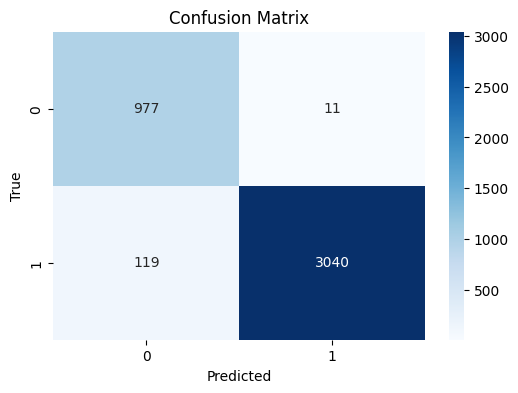

In [16]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, cmap="Blues", fmt="d")
plt.title("Матрица ошибок")
plt.xlabel("Предсказание")
plt.ylabel("Истинна")
plt.show()

In [17]:
X_test = test.copy()
X_test_scaled = scaler.transform(X_test)

test_pred = model.predict(X_test_scaled)

submission = pd.DataFrame({
    "index": range(len(test_pred)),
    "TargetClass": test_pred
})

submission.to_csv("submission_6.csv", index=False)